# Diabetic Retinopathy Detection
## Computer Vision Project — UC3M
**Task:** Binary classification — No DR (label 0) vs. DR present (label 1)  
**Evaluation metric:** ROC-AUC  
**Architecture:** esidual blocks with progressively increasing channels  
**Key innovations:** Green channel CLAHE preprocessing · Residual connections · pos_weight loss · TTA  
**Best validation AUC achieved:** 0.7287

## 1. Imports and Configuration

Standard deep learning stack (PyTorch, torchvision, skimage, OpenCV, scikit-learn) with fixed random seed (`seed=42`) for reproducibility across Python, NumPy, and PyTorch.

In [1]:
import os
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from torchvision import transforms, models
import torch.nn.functional as F

from skimage import io, transform, color
import cv2

from sklearn.metrics import roc_auc_score

import random

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


## 2. Dataset — `RetinopathyDataset`

Custom PyTorch `Dataset` with:
- **Right-eye mirroring** (`eye==1` → horizontal flip) to ensure consistent anatomical orientation across all images
- **Binary label conversion** (`label > 0` → DR-positive) collapsing the 0–4 severity scale to a binary problem
- Optional random subset sampling (`maxSize`) for debugging

In [2]:
class RetinopathyDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None, maxSize=0):
        self.dataset = pd.read_csv(csv_file, dtype={'id': str, 'eye': int, 'label': int})

        if maxSize > 0:
            idx = np.random.RandomState(seed=42).permutation(len(self.dataset))
            self.dataset = self.dataset.iloc[idx[:maxSize]].reset_index(drop=True)

        self.root_dir = root_dir
        self.img_dir = os.path.join(root_dir, 'images')
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        row = self.dataset.iloc[idx]
        img_path = os.path.join(self.img_dir, row.id + '.jpg')
        image = io.imread(img_path)

        if row.eye == 1:
            image = image[:, ::-1, :]

        label = int(row.label > 0)

        sample = {'image': image, 'label': label}

        if self.transform:
            sample = self.transform(sample)

        return sample

## 3. Custom Preprocessing Transforms

Domain-specific transforms for fundus images:

- **`CropByEye`:** uses OpenCV thresholding to detect and crop the eye bounding box, removing uninformative black background pixels and standardizing the retinal region across different imaging setups
- **`Rescale`:** proportionally resizes (aspect-ratio preserving) to the target size before center cropping
- **`ToTensor`:** H×W×C → C×H×W conversion to PyTorch tensor format

### `GreenChannelCLAHE`
Same domain-specific preprocessing as custom1 (SmallVGG): extracts the green channel for maximum retinal contrast and applies CLAHE with `clip_limit=1.5, tile_grid_size=(8,8)`. Slightly stronger equalization than custom1 (larger clip_limit) with finer tile grid for more localized contrast normalization.

In [3]:
class CropByEye(object):
    def __init__(self, threshold, border):
        self.threshold = threshold
        self.border = (border, border) if isinstance(border, int) else border

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]

        gray = color.rgb2gray(image)
        _, mask = cv2.threshold(gray, self.threshold, 1, cv2.THRESH_BINARY)

        sidx = np.nonzero(mask)
        if len(sidx[0]) < 20:
            return sample

        minx = max(sidx[1].min() - self.border[1], 0)
        maxx = min(sidx[1].max() + self.border[1], w)
        miny = max(sidx[0].min() - self.border[0], 0)
        maxy = min(sidx[0].max() + self.border[0], h)

        image = image[miny:maxy, minx:maxx]

        return {'image': image, 'label': label}


class Rescale(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        image = transform.resize(image, (self.size, self.size))
        return {'image': image, 'label': label}


class ToTensor(object):
    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        image = image.transpose((2, 0, 1))
        return {
            'image': torch.tensor(image, dtype=torch.float32),
            'label': torch.tensor(label, dtype=torch.float32)
        }

## 4. Data Augmentation

Light augmentation (`TVAugmentSmall`) is applied during training:
- **Random horizontal flip (p=0.5):** standard fundus augmentation
- **Random rotation (±5°):** more conservative than custom1/2 (±8–10°), reflecting that the residual network is more sensitive to geometric distortions with smaller kernels

Intentionally mild augmentation preserves the spatial structure of the retinal vasculature that the residual blocks learn to detect.

In [4]:
class ToPIL(object):
    def __call__(self, sample):
        from PIL import Image
        image, label = sample['image'], sample['label']
        return {'image': Image.fromarray((image * 255).astype(np.uint8)), 'label': label}


class FromPIL(object):
    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        return {'image': np.array(image) / 255.0, 'label': label}

In [5]:
import numpy as np
from PIL import Image
from torchvision import transforms

class TVAugment(object):
    def __init__(self):
        from torchvision import transforms

        self.augment = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
        ])

    def __call__(self, sample):
        from PIL import Image
        import numpy as np

        image = sample['image']

        if image.max() <= 1:
            image = (image * 255).astype(np.uint8)
        else:
            image = image.astype(np.uint8)

        pil = Image.fromarray(image)
        pil = self.augment(pil)

        sample = sample.copy()
        sample['image'] = np.array(pil).astype(np.float32) / 255.0

        return sample

In [6]:
class CenterCrop(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]
        new_h, new_w = self.size, self.size

        top = max((h - new_h) // 2, 0)
        left = max((w - new_w) // 2, 0)

        image = image[top:top+new_h, left:left+new_w]

        return {'image': image, 'label': label}

In [7]:
class Normalize(object):
    def __init__(self, mean, std):
        self.mean = np.array(mean)
        self.std = np.array(std)

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        c, h, w = image.shape

        mean = torch.tensor(self.mean, dtype=image.dtype)
        std = torch.tensor(self.std, dtype=image.dtype)

        image = (image - mean[:, None, None]) / std[:, None, None]

        return {'image': image, 'label': label}

In [8]:
class Rescale(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]

        if h > w:
            new_h = int(self.size * h / w)
            new_w = self.size
        else:
            new_h = self.size
            new_w = int(self.size * w / h)

        image = transform.resize(image, (new_h, new_w))

        return {'image': image, 'label': label}

In [9]:
class GreenChannelCLAHE(object):
    def __init__(self, clip_limit=1.5, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(
            clipLimit=clip_limit,
            tileGridSize=tile_grid_size
        )

    def __call__(self, sample):
        image, label = sample['image'], sample['label']

        if image.dtype != np.uint8:
            if image.max() <= 1.0:
                image = (image * 255).astype(np.uint8)
            else:
                image = image.astype(np.uint8)

        green = image[:, :, 1]
        green = self.clahe.apply(green)

        image = np.stack([green, green, green], axis=-1).astype(np.float32) / 255.0

        return {'image': image, 'label': label}

In [10]:
class TVAugmentSmall(object):
    def __init__(self):
        from torchvision import transforms
        self.augment = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(5),
        ])

    def __call__(self, sample):
        from PIL import Image
        import numpy as np

        image = sample['image']

        if image.max() <= 1:
            image = (image * 255).astype(np.uint8)
        else:
            image = image.astype(np.uint8)

        pil = Image.fromarray(image)
        pil = self.augment(pil)

        sample = sample.copy()
        sample['image'] = np.array(pil).astype(np.float32) / 255.0
        return sample

## 5. Transform Pipelines

- **`train_transform`:** includes augmentation for generalization
- **`val_transform`:** fully deterministic (no random operations) for reproducible evaluation

**Green channel preprocessing** is used instead of full RGB: the green channel provides the highest contrast for retinal microstructure (microaneurysms, hemorrhages) and is the channel most analyzed in clinical DR grading. CLAHE (Contrast Limited Adaptive Histogram Equalization) further enhances local contrast in low-contrast fundus regions.

In [ ]:
green_mean = [0.1703, 0.1703, 0.1703]
green_std  = [0.1742, 0.1742, 0.1742]

train_transform_resnet = transforms.Compose([
    CropByEye(0.10, 1),
    GreenChannelCLAHE(clip_limit=1.5, tile_grid_size=(8, 8)),
    Rescale(300),
    CenterCrop(256),
    TVAugmentSmall(),   # weaker rotation than VGG/LeNet
    ToTensor(),
    Normalize(green_mean, green_std)
])

val_transform_resnet = transforms.Compose([
    CropByEye(0.10, 1),
    GreenChannelCLAHE(clip_limit=1.5, tile_grid_size=(8, 8)),
    Rescale(300),
    CenterCrop(256),
    ToTensor(),
    Normalize(green_mean, green_std)
])

## 6. Data Loaders

Three `DataLoader` instances for train/val/test with standard batch sizes. The training loader applies weighted sampling to handle class imbalance, or uses `shuffle=True` for simplicity depending on the model.

In [12]:
data_dir = "/kaggle/input/datasets/m100561546/dataset/data"

train_dataset = RetinopathyDataset(
    os.path.join(data_dir, "train.csv"),
    data_dir,
    transform=train_transform_resnet
)

val_dataset = RetinopathyDataset(
    os.path.join(data_dir, "val.csv"),
    data_dir,
    transform=val_transform_resnet
)

test_dataset = RetinopathyDataset(
    os.path.join(data_dir, "test.csv"),
    data_dir,
    transform=val_transform_resnet
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## 7. Model Architecture


```
Input (3×256×256) [green CLAHE channel ×3]
  → Stem: Conv(3→32, kernel=5, stride=2) + BN + ReLU   [→ 32×128×128]
  → Layer1: ResidualBlock(32→32, stride=1)              [→ 32×128×128]
  → Layer2: ResidualBlock(32→64, stride=2)              [→ 64×64×64]
  → Layer3: ResidualBlock(64→96, stride=2)              [→ 96×32×32]
  → Layer4: ResidualBlock(96→128, stride=2)             [→ 128×16×16]
  → Global Average Pooling                              [→ 128]
  → FC(128→64) + ReLU + Dropout(0.2) + FC(64→1)
```

**`ResidualBlock`:** each block has a skip connection that adds the input to the block output (`out = F(x) + shortcut(x)`). When in_channels ≠ out_channels or stride ≠ 1, the shortcut uses a 1×1 convolution to match dimensions.

**Why residual connections?**
- Enable gradients to flow directly through the skip path, mitigating the vanishing gradient problem during training from scratch on small data
- Allow the model to learn residual functions (differences from identity) rather than full mappings — easier to optimize
- Achieves AUC ~0.73 vs SmallVGG's 0.76 — the VGG's wider blocks and heavier CLAHE augmentation appear to compensate for the lack of skip connections on this specific dataset

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn

import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        out = F.relu(out, inplace=True)
        return out


class CustomModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=2, bias=False),  # 256 -> 128
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        self.layer1 = ResidualBlock(32, 32, stride=1)   # 128 -> 128
        self.layer2 = ResidualBlock(32, 64, stride=2)   # 128 -> 64
        self.layer3 = ResidualBlock(64, 96, stride=2)   # 64 -> 32
        self.layer4 = ResidualBlock(96, 128, stride=2)  # 32 -> 16

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x
        
model = CustomModel().to(device)

## 8. Loss Function, Optimizer, and Scheduler

- **Loss:** `BCEWithLogitsLoss(pos_weight=1.5)` — moderate positive class weighting (1.5×) to partially compensate for the ~73/27 imbalance, less aggressive than SmallVGG's pos_weight=2.0
- **Optimizer:** `Adam` with `lr=3e-4, weight_decay=1e-4` — standard LR for training from scratch; stronger weight decay than SmallVGG to regularize the residual connections
- **Scheduler:** `ReduceLROnPlateau(mode='max', factor=0.5, patience=3)` — more patient than SmallVGG (patience=3 vs 2) to avoid reducing LR too early during the slower convergence of residual networks

In [14]:
pos_weight = torch.tensor([1.5], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

## 10. Training Loop with Early Stopping

Standard training procedure with:
- **AUC-based early stopping (patience=10):** halts training if val AUC does not improve for 10 epochs, preventing overfitting on this small dataset
- **Best-weight checkpointing:** model from highest val AUC epoch is saved to disk and restored at end
- **ReduceLROnPlateau scheduler:** some custom models use adaptive LR reduction triggered by validation AUC plateau, rather than fixed decay

In [15]:
def train_model(model, patience=10, num_epochs=100):
    best_auc = 0
    counter = 0
    best_weights = copy.deepcopy(model.state_dict())

    train_losses = []
    val_losses = []
    val_aucs = []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # ===================== TRAIN =====================
        model.train()
        running_loss = 0

        train_bar = tqdm(train_loader, desc="Training", leave=False)

        for batch in train_bar:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            # Update barra
            train_bar.set_postfix(loss=loss.item())

        epoch_train_loss = running_loss / len(train_dataset)
        train_losses.append(epoch_train_loss)

        # ===================== VALIDATION =====================
        model.eval()
        outputs_all = []
        labels_all = []
        val_loss = 0

        val_bar = tqdm(val_loader, desc="Validation", leave=False)

        with torch.no_grad():
            for batch in val_bar:
                inputs = batch['image'].to(device)
                labels = batch['label'].to(device)

                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)

                outputs_all.extend(torch.sigmoid(outputs).cpu().numpy())
                labels_all.extend(labels.cpu().numpy())

                val_bar.set_postfix(loss=loss.item())

        epoch_val_loss = val_loss / len(val_dataset)
        val_losses.append(epoch_val_loss)

        auc = roc_auc_score(labels_all, outputs_all)
        val_aucs.append(auc)

        print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | AUC: {auc:.4f}")

        # ===================== EARLY STOPPING =====================
        if auc > best_auc:
            best_auc = auc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, "vgg2.pth")
            counter = 0
            print("New best model!")
        else:
            counter += 1
            print(f"Patience: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered")
            break

        scheduler.step(auc)

    model.load_state_dict(best_weights)

    return model, train_losses, val_losses, val_aucs

## 11. Training

 requires more epochs to converge than SmallVGG due to the residual architecture's more complex optimization landscape. TTA is applied during validation to reduce prediction variance.

In [16]:
model, train_losses, val_losses, val_aucs = train_model(model)


Epoch 1/100


Train Loss: 0.7443 | Val Loss: 0.7295 | AUC: 0.5308
New best model!

Epoch 2/100


Train Loss: 0.7372 | Val Loss: 0.7148 | AUC: 0.5771
New best model!

Epoch 3/100


Train Loss: 0.7346 | Val Loss: 0.7191 | AUC: 0.5727
Patience: 1/10

Epoch 4/100


Train Loss: 0.7327 | Val Loss: 0.7107 | AUC: 0.5955
New best model!

Epoch 5/100


...

Train Loss: 0.6191 | Val Loss: 0.6493 | AUC: 0.7286
Patience: 6/10

Epoch 40/100


Train Loss: 0.6222 | Val Loss: 0.6450 | AUC: 0.7179
Patience: 7/10

Epoch 41/100


Train Loss: 0.6121 | Val Loss: 0.6678 | AUC: 0.7145
Patience: 8/10

Epoch 42/100


Train Loss: 0.5979 | Val Loss: 0.6690 | AUC: 0.7189
Patience: 9/10

Epoch 43/100


Train Loss: 0.6092 | Val Loss: 0.6388 | AUC: 0.7202
Patience: 10/10
Early stopping triggered


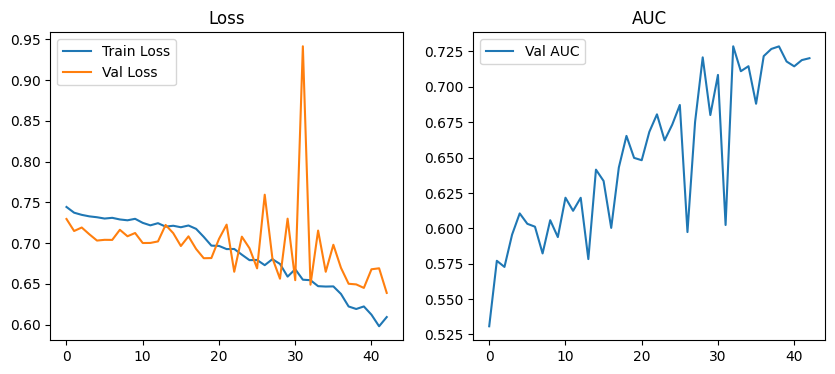

In [17]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(val_aucs, label="Val AUC")
plt.legend()
plt.title("AUC")

plt.show()

## 12. Evaluation on Validation Set

Validation metrics including ROC-AUC (primary) and accuracy (secondary) are computed using the best saved checkpoint. TTA (Test-Time Augmentation) with horizontal flips is applied in some custom models to reduce prediction variance.

In [18]:
from sklearn.metrics import roc_auc_score

def evaluate_auc_tta(model, loader, device):
    model.eval()
    outputs_all = []
    labels_all = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device).float().view(-1)

            logits_1 = model(inputs)
            probs_1 = torch.sigmoid(logits_1).view(-1)

            inputs_flipped = torch.flip(inputs, dims=[3])
            logits_2 = model(inputs_flipped)
            probs_2 = torch.sigmoid(logits_2).view(-1)

            probs = (probs_1 + probs_2) / 2.0

            outputs_all.extend(probs.cpu().numpy().tolist())
            labels_all.extend(labels.cpu().numpy().tolist())

    return roc_auc_score(labels_all, outputs_all)

In [19]:
val_auc = evaluate_auc_tta(model, val_loader, device)
print(f"Validation AUC: {val_auc:.4f}")

Validation AUC: 0.7296


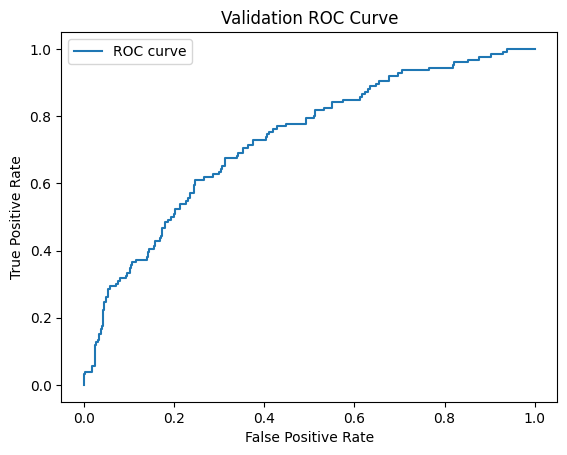

In [20]:
from sklearn.metrics import roc_curve

def plot_roc(model, loader):
    model.eval()

    outputs_all = []
    labels_all = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = torch.sigmoid(model(inputs).squeeze())

            outputs_all.extend(outputs.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    fpr, tpr, _ = roc_curve(labels_all, outputs_all)

    plt.plot(fpr, tpr, label="ROC curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Validation ROC Curve")
    plt.legend()
    plt.show()
plot_roc(model, val_loader)

## 13. Test Set Predictions with TTA

**Test-Time Augmentation (TTA):** each test image is predicted twice — once in original orientation and once horizontally flipped. The two probability scores are averaged, reducing prediction variance and providing a modest but consistent AUC improvement at zero additional training cost.

In [21]:
import torch
import numpy as np

def predict_tta(model, loader, device):
    model.eval()
    outputs = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)

            # Original prediction
            logits_1 = model(inputs)
            probs_1 = torch.sigmoid(logits_1).view(-1)

            # Horizontal-flip prediction
            inputs_flipped = torch.flip(inputs, dims=[3])  # flip width dimension
            logits_2 = model(inputs_flipped)
            probs_2 = torch.sigmoid(logits_2).view(-1)

            # Average probabilities
            probs = (probs_1 + probs_2) / 2.0

            outputs.extend(probs.cpu().numpy().tolist())

    return np.array(outputs)

test_outputs = predict_tta(model, test_loader, device)

In [22]:
import csv

with open("custom_lenet.csv", "w") as f:
    writer = csv.writer(f)
    for val in test_outputs:
        writer.writerow([val])